<a href="https://colab.research.google.com/github/tishawest/courses/blob/master/COP528_AI_and_Applied_Machine_Learning_Coursework_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COP528 AI and Applied Machine Learning Coursework: Image Classification
## Student ID: F416670



In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, VGG16, EfficientNetB0
from tensorflow.keras.utils import image_dataset_from_directory, load_img, img_to_array
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.models import load_model
import keras
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, ConfusionMatrixDisplay

In [64]:
# load the data into variables

train_dir = '/content/drive/MyDrive/Machine_Learning/imageset/train'
test_dir = '/content/drive/MyDrive/Machine_Learning/imageset/test'

In [66]:
# check number of files in each class to ensure balanced dataset

for root, dir, files in os.walk(train_dir):
  print(f'{os.path.basename(root)}: {len(files)}')

for root, dir, files in os.walk(test_dir):
  print(f'{os.path.basename(root)}: {len(files)}')

train: 0
n03394916: 956
n03417042: 961
n03445777: 951
n02102040: 955
n03425413: 931
n03888257: 960
n03028079: 941
n03000684: 858
n01440764: 963
n02979186: 993
test: 0
n03394916: 394
n03417042: 389
n03445777: 399
n02102040: 395
n03425413: 419
n03888257: 390
n03028079: 409
n03000684: 386
n01440764: 387
n02979186: 357


In [65]:
# create a dictionary for class names

class_names_dict = {
    "n03394916": "french horns",
    "n03417042": "trucks",
    "n03445777": "golf balls",
    "n02102040": "dogs",
    "n03425413": "gas pumps",
    "n03888257": "parachutes",
    "n03028079": "churches",
    "n03000684": "chainsaws",
    "n01440764": "fish",
    "n02979186": "radios",
    }

Found 9469 files belonging to 10 classes.


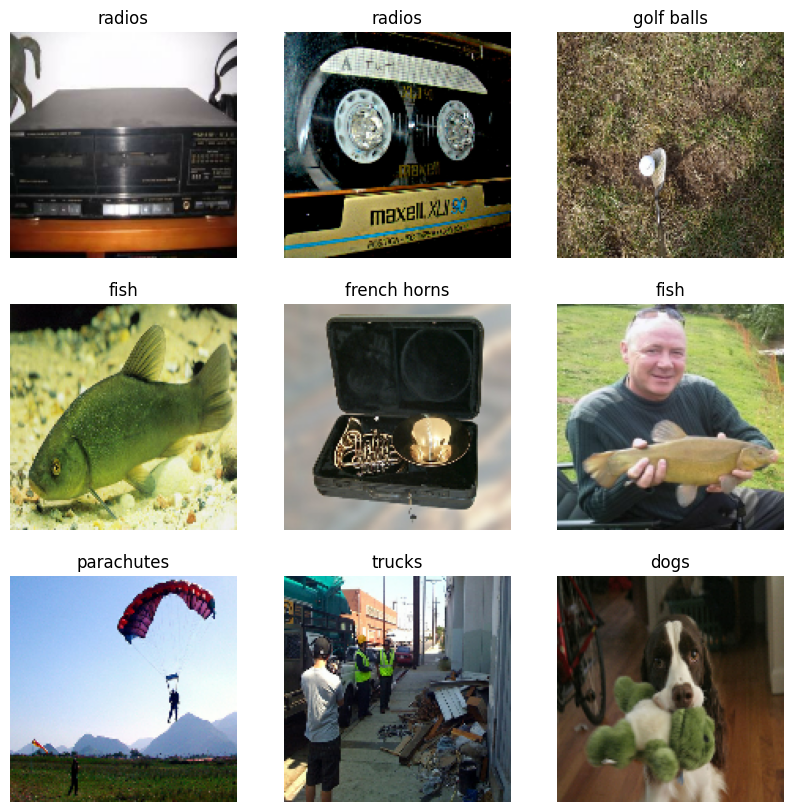

In [77]:
# create a quick sample dataset to view images

SAMPLE_BATCH_SIZE = 32
SAMPLE_IMG_SIZE = (144, 144)

# create sample

sample_dataset = image_dataset_from_directory(
    train_dir,
    image_size=SAMPLE_IMG_SIZE,
    batch_size=SAMPLE_BATCH_SIZE,
)

# display sample of images

sample_class_names = sample_dataset.class_names
updated_sample_class_names = [class_names_dict[class_name] for class_name in sample_dataset.class_names]

plt.figure(figsize=(10, 10))
for images, labels in sample_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(updated_sample_class_names[labels[i]])
        plt.axis("off")

In [68]:
# create functions to load, augment, normalize data

def load_data(train_directory, test_directory, batch_size, img_size):
  """Loads data into train, validation and test datasets"""

  train_dataset, val_dataset = image_dataset_from_directory(
    train_directory,
    label_mode="int",
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=img_size,
    batch_size=batch_size
  )

  test_dataset = image_dataset_from_directory(
      test_directory,
      label_mode="int",
      shuffle=True,
      image_size=img_size,
      batch_size=batch_size
  )

  return train_dataset, val_dataset, test_dataset


# Below code adapted from image classification guide:
# https://keras.io/examples/vision/image_classification_from_scratch/
# Accessed 19th April 2026

def augment_data(dataset):
  """Augments dataset images to introduce variation"""

  augmentation_layers = keras.Sequential(
    [
      layers.RandomFlip("horizontal"),
      layers.RandomRotation(0.1),
      layers.RandomContrast(0.2),
    ]
    )

  augmented_dataset = dataset.map(
  lambda x, y: (augmentation_layers(x, training=True), y))
  return augmented_dataset


def rescale_images(images):
  """Rescales images between 0 and 1"""

  rescaled_images = layers.Rescaling(1./255)(images)
  return rescaled_images


# function to use buffered pre-fetching to prevent I/O becoming blocking
# suggestion by Chollet, F in https://kirenz.github.io/deep-learning/docs/image_classification_from_scratch.html

def apply_prefetch(norm_train_dataset, norm_val_dataset, norm_test_dataset):
  """Apply prefetch to data set to preveny I/O becoming blocking"""

  norm_train_dataset = norm_train_dataset.prefetch(buffer_size=32)
  norm_val_dataset = norm_val_dataset.prefetch(buffer_size=32)
  norm_test_dataset = norm_test_dataset.prefetch(buffer_size=32)
  return norm_train_dataset, norm_val_dataset, norm_test_dataset


# code adapted from Aionlinecourse
# Found at: https://www.aionlinecourse.com/blog/how-to-plot-confusion-matrix-for-prefetched-dataset-in-tensorflow

def get_eval_metrics(norm_test_dataset, test_dataset, model):
  """Shows evaluation metrics for model"""

  y_pred = []  # store predicted labels
  y_true = []  # store true labels

  # iterate over the dataset
  for image_batch, label_batch in norm_test_dataset:
    # append true labels
    y_true.append(label_batch)
    # compute predictions
    preds = model.predict(image_batch, verbose=0)
    # append predicted labels
    y_pred.append(np.argmax(preds, axis = - 1))

  # convert the true and predicted labels into tensors
  correct_labels = tf.concat([item for item in y_true], axis = 0)
  predicted_labels = tf.concat([item for item in y_pred], axis = 0)

  # update class names to readable names using dictionary
  updated_class_names = [
      class_names_dict[class_name]
      for class_name in test_dataset.class_names]

  # create and plot confusion matrix
  conf_matrix = confusion_matrix(predicted_labels, correct_labels)
  cm_graph = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                                    display_labels=updated_class_names)
  cm_graph.plot()
  plt.xticks(rotation=45)
  plt.show()

  # calculate precision, recall, and f1 with weighted average to account for class imbalance
  print(f"""Weighted Precision score: {precision_score(predicted_labels,
                                                       correct_labels,
                                                       average='weighted')}""")
  print(f"""Weighted Recall score: {recall_score(predicted_labels,
                                                 correct_labels,
                                                 average='weighted')}""")
  print(f"""Weighted F1 score: {f1_score(predicted_labels,
                                         correct_labels,
                                         average='weighted')}""")

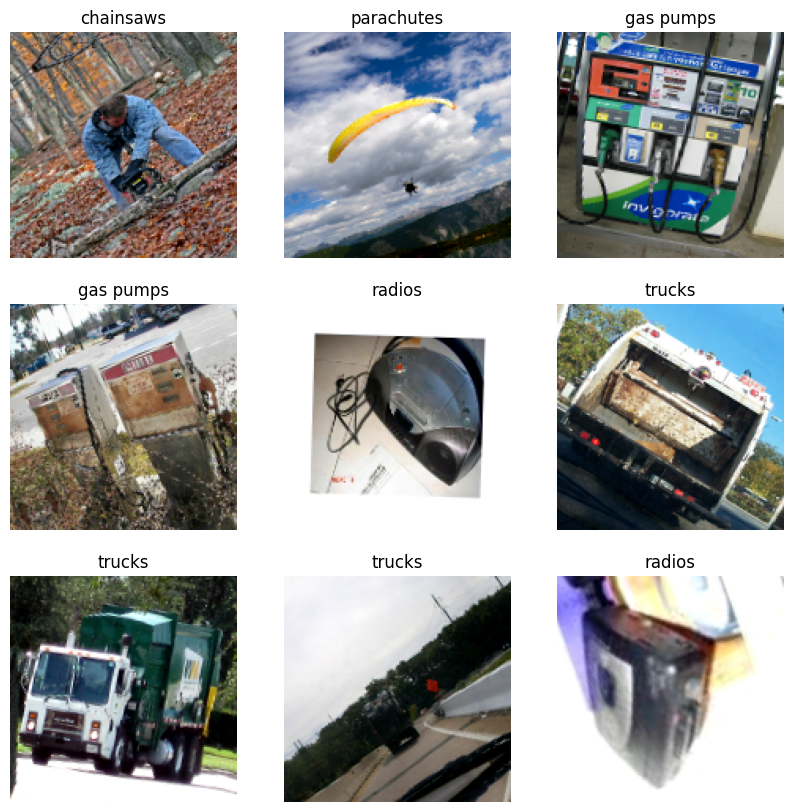

In [85]:
# display sample of images with augmentation applied
augmented_sample_data = augment_data(sample_dataset)

plt.figure(figsize=(10, 10))
for images, labels in augmented_sample_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(updated_sample_class_names[labels[i]])
        plt.axis("off")

# Model 1: Resnet 50

For the Resnet50 model, I used the code from the tutorial provided by Feit. E, 'Alien vs Predator Image Classification with ResNet50 (Tutorial)' , with some slight adaptations to the dataset loading, from the following site:

https://eranfeit.net/alien-vs-predator-image-classification-with-resnet50-complete-tutorial/

In [70]:
# load the data with resnet required img sizes

RESNET_BATCH_SIZE = 32
RESNET_IMG_SIZE = (224, 224)
RESNET_IMG_SHAPE = (224, 224, 3)

resnet_train, resnet_val, resnet_test = load_data(train_dir, test_dir, RESNET_BATCH_SIZE, RESNET_IMG_SIZE)

Found 9469 files belonging to 10 classes.
Using 7576 files for training.
Using 1893 files for validation.
Found 3925 files belonging to 10 classes.


In [71]:
# augment the train data
aug_resnet_train = augment_data(resnet_train)

# normalize all three datasets
norm_resnet_train = aug_resnet_train_dataset.map(
  lambda x, y: (rescale_images(x), y))

norm_resnet_val = resnet_val.map(
  lambda x, y: (rescale_images(x), y))

norm_resnet_test = resnet_test.map(
  lambda x, y: (rescale_images(x), y))

In [72]:
# load the resnet50 model, imagenet weights and exclude top layers
RESNET_IMG_SHAPE = (224, 224, 3)

myResnet = ResNet50(input_shape= RESNET_IMG_SHAPE,
                    weights="imagenet",
                    include_top=False
                    )

In [73]:
# freeze pre-trained layers
for layer in myResnet.layers:
  layer.trainable = False

In [74]:
# get number of classes from dataset
num_classes = len(resnet_train.class_names)

In [75]:
# reduce dimensions with a global average pooling layer
global_average_pooling_layer = tf.keras.layers.GlobalAveragePooling2D()(myResnet.output)

# # flatten the pooled features into single vector
PlusFlattenLayer = Flatten()(global_average_pooling_layer)

# add the final dense layer with softmax activation as its multiclass
predictionLayer = Dense(num_classes, activation='softmax')(PlusFlattenLayer)

# define inputs and outputs of final model
resnet_model = models.Model(inputs=myResnet.input, outputs=predictionLayer)

# compile model with categorical cross entropy and Adam optimizer
resnet_model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=['accuracy']
              )

In [78]:
# use buffered pre-fetching to prevent I/O becoming blocking

norm_resnet_train, norm_resnet_val, norm_resnet_test = apply_prefetch(
    norm_resnet_train,
    norm_resnet_val,
    norm_resnet_test
    )

In [79]:
# setting training parameters
EPOCHS = 200
resnet_model_file = '/content/drive/MyDrive/Machine_Learning/resnet50_model.h5'

# importing callbacks for better training controls
callbacks = [
    ModelCheckpoint(resnet_model_file, verbose=1, save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_accuracy', patience=10, factor=0.1, verbose=1, min_lr=1e-6),
    EarlyStopping(monitor='val_accuracy', patience=30, verbose=1)
]

# train the model with
r = resnet_model.fit(norm_resnet_train,
              validation_data = norm_resnet_val,
              epochs=EPOCHS,
              steps_per_epoch=len(norm_resnet_train),
              validation_steps=len(norm_resnet_val),
              callbacks=callbacks
              )

#
best_val_accuracy = max(r.history['val_accuracy'])
print(f'Best validation accuracy: {best_val_accuracy}')

# plot accuracy curves
plt.plot(r.history['accuracy'], label='train accuracy')
plt.plot(r.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# plot loss curves
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [81]:
# define images and dataset classes
loaded_resnet50_model = load_model('/content/drive/MyDrive/Machine_Learning/resnet50_model.h5')

scores = loaded_resnet50_model.evaluate(norm_resnet_test, verbose=0)
print('Test loss:', scores[0])
print('Test accuracy:', scores[1])

In [ ]:
# get evaluation metrics for resnet model
get_eval_metrics(norm_resnet_test, resnet_test, loaded_resnet50_model)

## Model 2: VGG16

In [ ]:
# load the data with vgg required img sizes

VGG_BATCH_SIZE = 32
VGG_IMG_SIZE = (224, 224)
VGG_IMG_SHAPE = (224, 224, 3)

vgg_train, vgg_val, vgg_test = load_data(train_dir, test_dir, VGG_BATCH_SIZE, VGG_IMG_SIZE)

In [ ]:
# augment the train data
aug_vgg_train = augment_data(vgg_train)

# normalize all three datasets
norm_vgg_train = aug_vgg_train.map(
  lambda x, y: (rescale_images(x), y))

norm_vgg_val = resnet_val.map(
  lambda x, y: (rescale_images(x), y))

norm_vgg_test = resnet_test.map(
  lambda x, y: (rescale_images(x), y))

In [ ]:
# load the vgg16 model, imagenet weights and exclude top layers

myvgg16 = VGG16(input_shape= VGG_IMG_SHAPE,
                    weights="imagenet",
                    include_top=False
                    )

In [ ]:
# freeze pre-trained layers
for layer in myvgg16.layers:
  layer.trainable = False

In [ ]:
# get number of classes from dataset
num_classes = len(vgg_train.class_names)

In [ ]:
# reduce dimensions with a global average pooling layer
global_average_pooling_layer = tf.keras.layers.GlobalAveragePooling2D()(myvgg16.output)

# # flatten the pooled features into single vector
PlusFlattenLayer = Flatten()(global_average_pooling_layer)

# add the final dense layer with softmax activation as its multiclass
predictionLayer = Dense(num_classes, activation='softmax')(PlusFlattenLayer)

# define inputs and outputs of final model
vgg_model = models.Model(inputs=myvgg16.input, outputs=predictionLayer)

# compile model with categorical cross entropy and Adam optimizer
vgg_model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=['accuracy']
              )

In [ ]:
# use buffered pre-fetching to prevent I/O becoming blocking

norm_vgg_train, norm_vgg_val, norm_vgg_test = apply_prefetch(
    norm_vgg_train,
    norm_vgg_val,
    norm_vgg_test
    )

In [ ]:
# setting training parameters
EPOCHS = 200
vgg_model_file = '/content/drive/MyDrive/Machine_Learning/vgg16_model.h5'

# importing callbacks for better training controls
callbacks = [
    ModelCheckpoint(vgg_model_file, verbose=1, save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_accuracy', patience=10, factor=0.1, verbose=1, min_lr=1e-6),
    EarlyStopping(monitor='val_accuracy', patience=30, verbose=1)
]

# train the model
r = vgg_model.fit(norm_vgg_train,
              validation_data = norm_vgg_val,
              epochs=EPOCHS,
              steps_per_epoch=len(norm_vgg_train),
              validation_steps=len(norm_vgg_val),
              callbacks=callbacks
              )

# get validation accuracy
best_val_accuracy = max(r.history['val_accuracy'])
print(f'Best validation accuracy: {best_val_accuracy}')

# plot accuracy curves
plt.plot(r.history['accuracy'], label='train accuracy')
plt.plot(r.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# plot loss curves
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
# define images and dataset classes
loaded_vgg_model = load_model('/content/drive/MyDrive/Machine_Learning/vgg16_model.h5')

scores = loaded_vgg_model.evaluate(norm_vgg_test, verbose=0)
print('Test loss:', scores[0])
print('Test accuracy:', scores[1])

In [ ]:
# get evaluation metrics for vgg16 model
get_eval_metrics(norm_vgg_test, vgg_test, loaded_vgg_model)

## Model 3: EfficientNetB0



In [84]:
# load the data with efficientnet required img sizes

EFFNET_BATCH_SIZE = 32
EFFNET_IMG_SIZE = (224, 224)
EFFNET_IMG_SHAPE = (224, 224, 3)

effnet_train, effnet_val, effnet_test = load_data(train_dir, test_dir, EFFNET_BATCH_SIZE, EFFNET_IMG_SIZE)

Found 9469 files belonging to 10 classes.
Using 7576 files for training.
Using 1893 files for validation.
Found 3925 files belonging to 10 classes.


In [ ]:
# augment the train data
aug_effnet_train = augment_data(effnet_train)

# normalize all three datasets
norm_effnet_train = aug_effnet_train.map(
  lambda x, y: (rescale_images(x), y))

norm_effnet_val = effnet_val.map(
  lambda x, y: (rescale_images(x), y))

norm_effnet_test = resnet_test.map(
  lambda x, y: (rescale_images(x), y))

In [ ]:
# load the efficientnet model, imagenet weights and exclude top layers

myeffnet = EfficientNetB0(input_shape= EFFNET_IMG_SHAPE,
                    weights="imagenet",
                    include_top=False
                    )

In [ ]:
# freeze pre-trained layers
for layer in myeffnet.layers:
  layer.trainable = False

In [ ]:
# get number of classes from dataset
num_classes = len(effnet_train.class_names)

In [ ]:
# reduce dimensions with a global average pooling layer
global_average_pooling_layer = tf.keras.layers.GlobalAveragePooling2D()(myeffnet.output)

# # flatten the pooled features into single vector
PlusFlattenLayer = Flatten()(global_average_pooling_layer)

# add the final dense layer with softmax activation as its multiclass
predictionLayer = Dense(num_classes, activation='softmax')(PlusFlattenLayer)

# define inputs and outputs of final model
effnet_model = models.Model(inputs=myeffnet.input, outputs=predictionLayer)

# compile model with categorical cross entropy and Adam optimizer
effnet_model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=['accuracy']
              )

In [ ]:
# use buffered pre-fetching to prevent I/O becoming blocking

norm_effnet_train, norm_effnet_val, norm_effnet_test = apply_prefetch(
    norm_effnet_train,
    norm_effnet_val,
    norm_effnet_test
    )

In [ ]:
# setting training parameters
EPOCHS = 200
effnet_model_file = '/content/drive/MyDrive/Machine_Learning/effnetB0_model.h5'

# importing callbacks for better training controls
callbacks = [
    ModelCheckpoint(effnet_model_file, verbose=1, save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_accuracy', patience=10, factor=0.1, verbose=1, min_lr=1e-6),
    EarlyStopping(monitor='val_accuracy', patience=30, verbose=1)
]

# train the model
r = effnet_model.fit(norm_effnet_train,
              validation_data = norm_effnet_val,
              epochs=EPOCHS,
              steps_per_epoch=len(norm_effnet_train),
              validation_steps=len(norm_effnet_val),
              callbacks=callbacks
              )

# get validation accuracy
best_val_accuracy = max(r.history['val_accuracy'])
print(f'Best validation accuracy: {best_val_accuracy}')

# plot accuracy curves
plt.plot(r.history['accuracy'], label='train accuracy')
plt.plot(r.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# plot loss curves
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
# define images and dataset classes
loaded_effnet_model = load_model('/content/drive/MyDrive/Machine_Learning/effnetB0_model.h5')

scores = loaded_effnet_model.evaluate(norm_effnet_test, verbose=0)
print('Test loss:', scores[0])
print('Test accuracy:', scores[1])

In [ ]:
# get evaluation metrics for vgg16 model
get_eval_metrics(norm_effnet_test, effnet_test, loaded_effnet_model)